# LS-LRSI: Exploratory Data Analysis
## Aranayake, Kegalle District, Sri Lanka

**Student Name:** Aabidha Rifky
**ICBT SIS ID:** CL/MCSDS/CMU/10/04
**Cardiff Met ID:** st20357374
**Module:** DAS7003 Geospatial Analysis
**Assessment:** PRAC1

---

## Purpose

`02_preprocessing.ipynb` produced nine aligned layers, all sharing the same 221 x 221 grid: elevation, slope, aspect, curvature, NDVI, distance to road, distance to stream, rainfall, and soil clay content. This notebook combines them into a single table, checks the data for issues, and examines the distribution and relationships between indicators before they are combined into the risk index in `04_index_construction.ipynb`.

## 1. Load Processed Layers into a Single Table

Each processed layer is currently a separate 221 x 221 grid stored in its own file. This section loads all nine, and reshapes each one from a 2D grid into a single column, so that every one of the 48,841 grid cells becomes one row in a table, with one column per indicator. This structure is what the summary statistics, histograms, and correlation analysis below are built on.

In [1]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

PROCESSED_DIR = "../data/processed"
FIGURE_DIR = "../outputs/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

layer_files = {
    "elevation_m": "dem_30m.tif",
    "slope_deg": "slope_30m.tif",
    "aspect_deg": "aspect_30m.tif",
    "curvature": "curvature_30m.tif",
    "ndvi": "ndvi_30m.tif",
    "dist_road_m": "dist_road_30m.tif",
    "dist_stream_m": "dist_stream_30m.tif",
    "rainfall_mm": "rainfall_30m.tif",
    "soil_clay_pct": "soil_clay_30m.tif",
}

layers = {}
layer_metadata = {}

for name, filename in layer_files.items():
    with rasterio.open(f"{PROCESSED_DIR}/{filename}") as src:
        arr = src.read(1)

        layers[name] = arr
        layer_metadata[name] = {
            "shape": arr.shape,
            "crs": src.crs,
            "transform": src.transform
        }

# Use elevation as the reference grid
reference = layer_metadata["elevation_m"]

for name, meta in layer_metadata.items():

    if meta["shape"] != reference["shape"]:
        raise ValueError(
            f"{name} has shape {meta['shape']} "
            f"but reference grid is {reference['shape']}"
        )

    if meta["crs"] != reference["crs"]:
        raise ValueError(
            f"{name} has CRS {meta['crs']} "
            f"but reference CRS is {reference['crs']}"
        )

    if meta["transform"] != reference["transform"]:
        raise ValueError(
            f"{name} is not aligned to the reference grid transform."
        )

grid_shape = reference["shape"]

print(f"Grid shape confirmed: {grid_shape}")
print(f"Coordinate system confirmed: {reference['crs']}")
print("All nine layers share the same shape, CRS, and grid alignment.")

data = pd.DataFrame(
    {
        name: arr.flatten()
        for name, arr in layers.items()
    }
)

print(
    f"Table shape: "
    f"{data.shape[0]} grid cells, "
    f"{data.shape[1]} indicators"
)

data.head()

Grid shape confirmed: (221, 221)
Coordinate system confirmed: EPSG:32644
All nine layers share the same shape, CRS, and grid alignment.
Table shape: 48841 grid cells, 9 indicators


,elevation_m,slope_deg,aspect_deg,curvature,ndvi,dist_road_m,dist_stream_m,rainfall_mm,soil_clay_pct
0,216.000000,9.244759,246.716431,0.005127,0.539689,108.166542,3270.0,296.290558,35.804348
1,220.485321,11.834031,269.451294,0.002823,0.580278,84.852814,3240.0,296.266327,35.804348
2,228.571274,14.237419,277.363617,0.000419,0.507817,60.000000,3210.0,296.242096,35.804348
3,235.583801,13.102160,292.709991,-0.002244,0.457930,30.000000,3180.0,296.217896,35.804348
4,241.453415,12.224784,319.652771,-0.004597,0.452148,0.000000,3150.0,296.193695,35.804348


The nine processed layers all share the expected 221 × 221 grid, EPSG:32644 coordinate reference system, and identical raster transform, confirming that they are spatially aligned before being combined. The resulting table contains 48,841 grid cells and nine variables. Explicit checks of shape, CRS, and transform are used so that a misaligned raster raises an error rather than being silently combined with the remaining layers.

In [2]:
missing_counts = data.isna().sum()
print("Missing values per indicator:")
print(missing_counts)

Missing values per indicator:
elevation_m      0
slope_deg        0
aspect_deg       0
curvature        0
ndvi             0
dist_road_m      0
dist_stream_m    0
rainfall_mm      0
soil_clay_pct    0
dtype: int64


No conventional missing (`NaN`) values are present across any of the nine processed layers. This confirms that the layers can be combined into a complete 48,841-row analysis table. For NDVI, coverage was additionally checked during `02_preprocessing.ipynb` for raster edge and numeric nodata artefacts; the final Sentinel-2 mosaic contained zero missing pixels and zero exact-zero edge artefacts before being used here.

## 2. Summary Statistics

This table shows the minimum, maximum, mean, and spread of each indicator across the full study area, giving a first check of whether the data is physically sensible before it goes into the risk index.

In [3]:
data.describe().round(2)

,elevation_m,slope_deg,aspect_deg,curvature,ndvi,dist_road_m,dist_stream_m,rainfall_mm,soil_clay_pct
count,48841.00,48841.00,48841.00,48841.00,48841.00,48841.00,48841.00,48841.00,48841.00
mean,226.69,12.02,178.41,-0.00,0.46,148.54,1660.66,295.42,35.77
std,46.26,6.42,103.72,0.00,0.07,124.88,971.83,21.63,1.15
min,55.89,0.05,0.00,-0.04,0.08,0.00,0.00,247.01,33.02
25%,196.34,7.09,84.06,-0.00,0.43,42.43,853.29,277.00,35.08
50%,224.05,11.30,187.34,-0.00,0.47,120.00,1626.93,296.83,35.77
75%,256.96,16.11,263.82,0.00,0.51,216.33,2412.34,315.35,36.52
max,371.77,57.56,359.97,0.02,0.66,697.78,4092.00,327.76,38.46


The descriptive statistics are consistent with the preprocessing results. Elevation ranges from approximately 55.9 to 371.8 m, while slope averages 12.0° and reaches a maximum of 57.6°, representing the mixture of valley terrain and steep hillsides within the study area. Rainfall ranges from approximately 247.0 to 327.8 mm.

Following the Sentinel-2 mosaic correction in `02_preprocessing.ipynb`, NDVI ranges from 0.08 to 0.66 with no artificial zero-valued edge cells. Corrected curvature ranges from approximately -0.038 to 0.023. Road distance ranges from 0 to approximately 698 m and stream distance from 0 to approximately 4.09 km, while interpolated soil clay content ranges from approximately 33.0% to 38.5%. All values therefore fall within physically plausible ranges for the study area.

In [4]:
# Physical validity checks
physical_checks = {
    "Slope outside 0-90 degrees":
        ((data["slope_deg"] < 0) |
         (data["slope_deg"] > 90)).sum(),

    "NDVI outside -1 to 1":
        ((data["ndvi"] < -1) |
         (data["ndvi"] > 1)).sum(),

    "Negative rainfall":
        (data["rainfall_mm"] < 0).sum(),

    "Negative road distance":
        (data["dist_road_m"] < 0).sum(),

    "Negative stream distance":
        (data["dist_stream_m"] < 0).sum(),

    "Soil clay outside 0-100%":
        ((data["soil_clay_pct"] < 0) |
         (data["soil_clay_pct"] > 100)).sum()
}

print("Physical validity checks:")
for check, count in physical_checks.items():
    print(f"  {check}: {count}")

# Statistical outlier screening using the IQR rule.
# These are flagged for inspection, not automatically removed.
outlier_columns = [
    "elevation_m",
    "slope_deg",
    "curvature",
    "ndvi",
    "dist_road_m",
    "dist_stream_m",
    "rainfall_mm",
    "soil_clay_pct"
]

outlier_results = []

for col in outlier_columns:

    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flagged = (
        (data[col] < lower) |
        (data[col] > upper)
    ).sum()

    outlier_results.append({
        "indicator": col,
        "lower_IQR_bound": lower,
        "upper_IQR_bound": upper,
        "flagged_cells": int(flagged),
        "flagged_percent": round(
            flagged / len(data) * 100,
            2
        )
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

Physical validity checks:
  Slope outside 0-90 degrees: 0
  NDVI outside -1 to 1: 0
  Negative rainfall: 0
  Negative road distance: 0
  Negative stream distance: 0
  Soil clay outside 0-100%: 0


,indicator,lower_IQR_bound,upper_IQR_bound,flagged_cells,flagged_percent
0,elevation_m,105.405464,347.894417,601,1.23
1,slope_deg,-6.432089,29.628183,355,0.73
2,curvature,-0.011466,0.011486,490,1.00
3,ndvi,0.307462,0.626139,1365,2.79
4,dist_road_m,-218.433609,477.193100,943,1.93
5,dist_stream_m,-1485.295441,4750.926483,0,0.00
6,rainfall_mm,219.473953,372.871292,0,0.00
7,soil_clay_pct,32.928600,38.677685,0,0.00


### Physical Validity and Outlier Screening

All physical-validity checks returned zero invalid observations: no slopes fell outside 0–90°, no NDVI values fell outside -1 to 1, rainfall and distance values were non-negative, and soil clay percentages remained within 0–100%.

The IQR screening identifies a small number of statistically extreme cells, including 2.79% of NDVI cells, 1.93% of road-distance cells, 1.23% of elevation cells, 1.00% of curvature cells, and 0.73% of slope cells. Rainfall, stream distance, and soil clay content produced no IQR outliers. These cells are retained rather than automatically removed because spatial extremes can represent genuine terrain or land-cover conditions, such as steep slopes, high elevations, sparse vegetation, or locations far from roads. Statistical outlier status alone is therefore not treated as evidence of erroneous geospatial data. Aspect is not screened using the IQR rule because it is a circular variable, where 0° and 360° represent the same direction.

## 3. Distribution of Each Indicator

Histograms show how spread out each indicator is across the study area. An indicator with most values clustered narrowly in one place is less useful for telling risky and safe ground apart than one with a wide spread, since a wide spread means the indicator actually varies meaningfully from location to location within Aranayake.                                                                                                                           Soil clay content is expected to show a fairly narrow, roughly bell-shaped distribution, since it was produced by smooth interpolation across a small number of sample points rather than measured independently at every cell, so sharp jumps or multiple peaks would not be expected here.                   

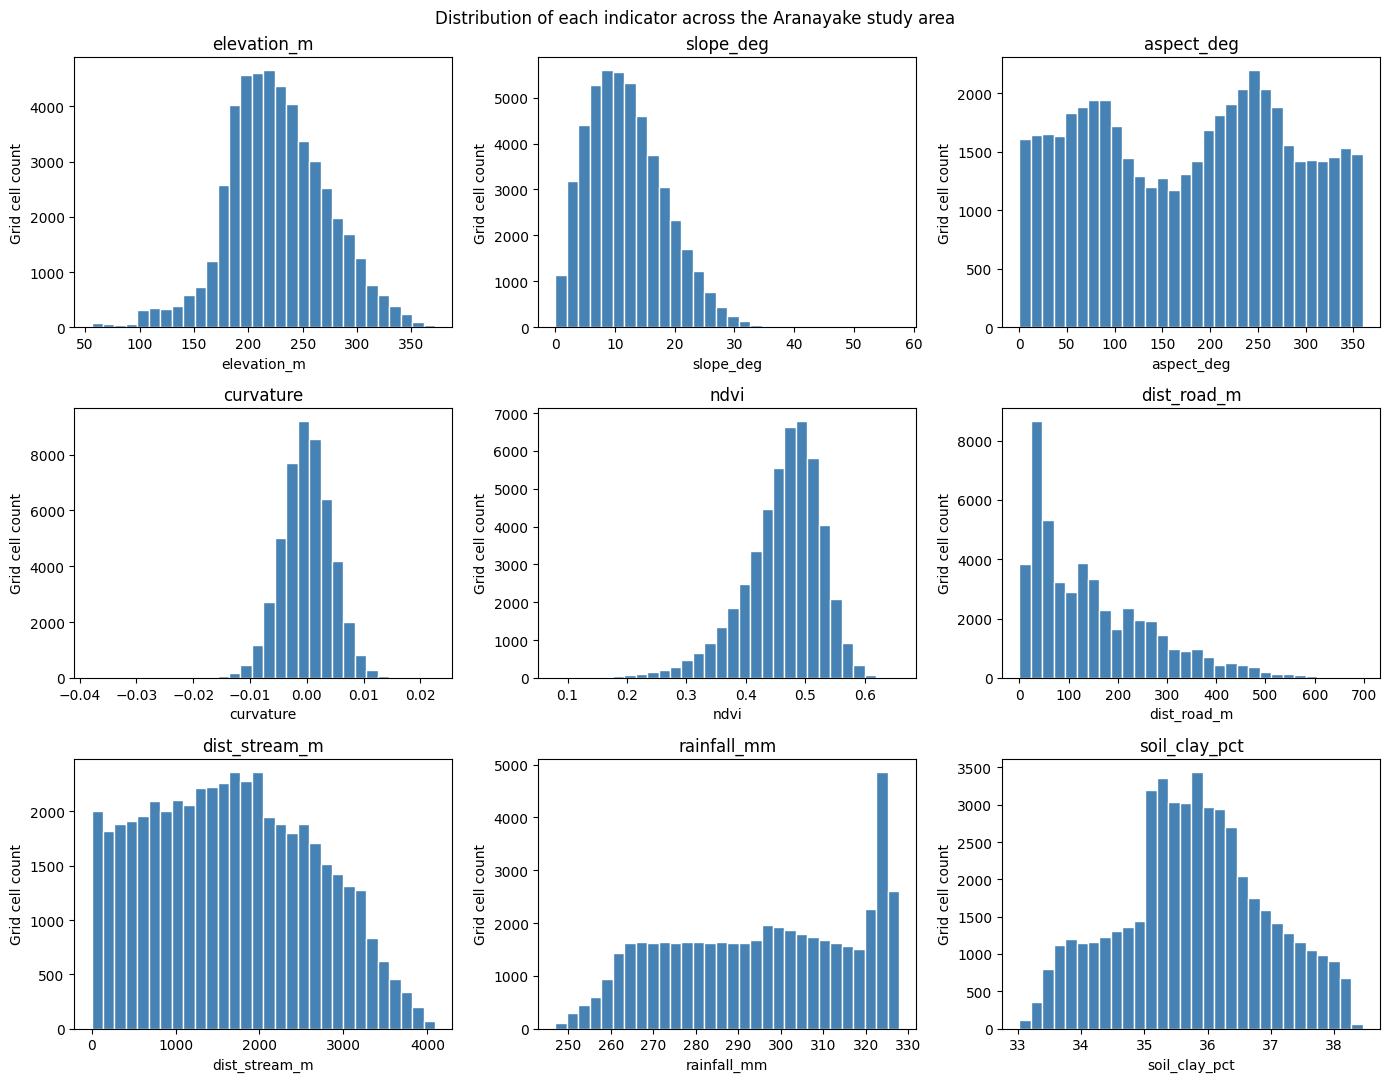

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
columns_to_plot = list(layer_files.keys())

for ax, col in zip(axes.flatten(), columns_to_plot):
    ax.hist(data[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Grid cell count")

plt.suptitle("Distribution of each indicator across the Aranayake study area")
plt.tight_layout()
plt.savefig("../outputs/figures/fig1_histograms.png", dpi=150)
plt.show()

Slope and rainfall are expected to show a fairly tight, unimodal distribution, most of the study area shares a broadly similar value, with a tail toward higher values in the steepest or wettest sections. Distance to road and distance to stream are expected to show a wider, more spread-out distribution, since these values grow steadily with distance from the nearest linear feature rather than clustering around one typical value. Aspect shows two clear peaks rather than an even spread, roughly 0-90 degrees and 200-300 degrees, with fewer cells facing the directions in between. This is consistent with Aranayake's valley and ridge terrain, where slopes tend to face one of two dominant directions rather than being randomly oriented, and reflects real landscape structure rather than a data issue.

## 3b. Spatial Distribution of Key Indicators

Histograms show the range and shape of each indicator's values but not where those values occur. This section maps five key indicators directly onto the study grid, so spatial patterns, clustering, ridges, valleys, can be checked visually rather than only statistically.

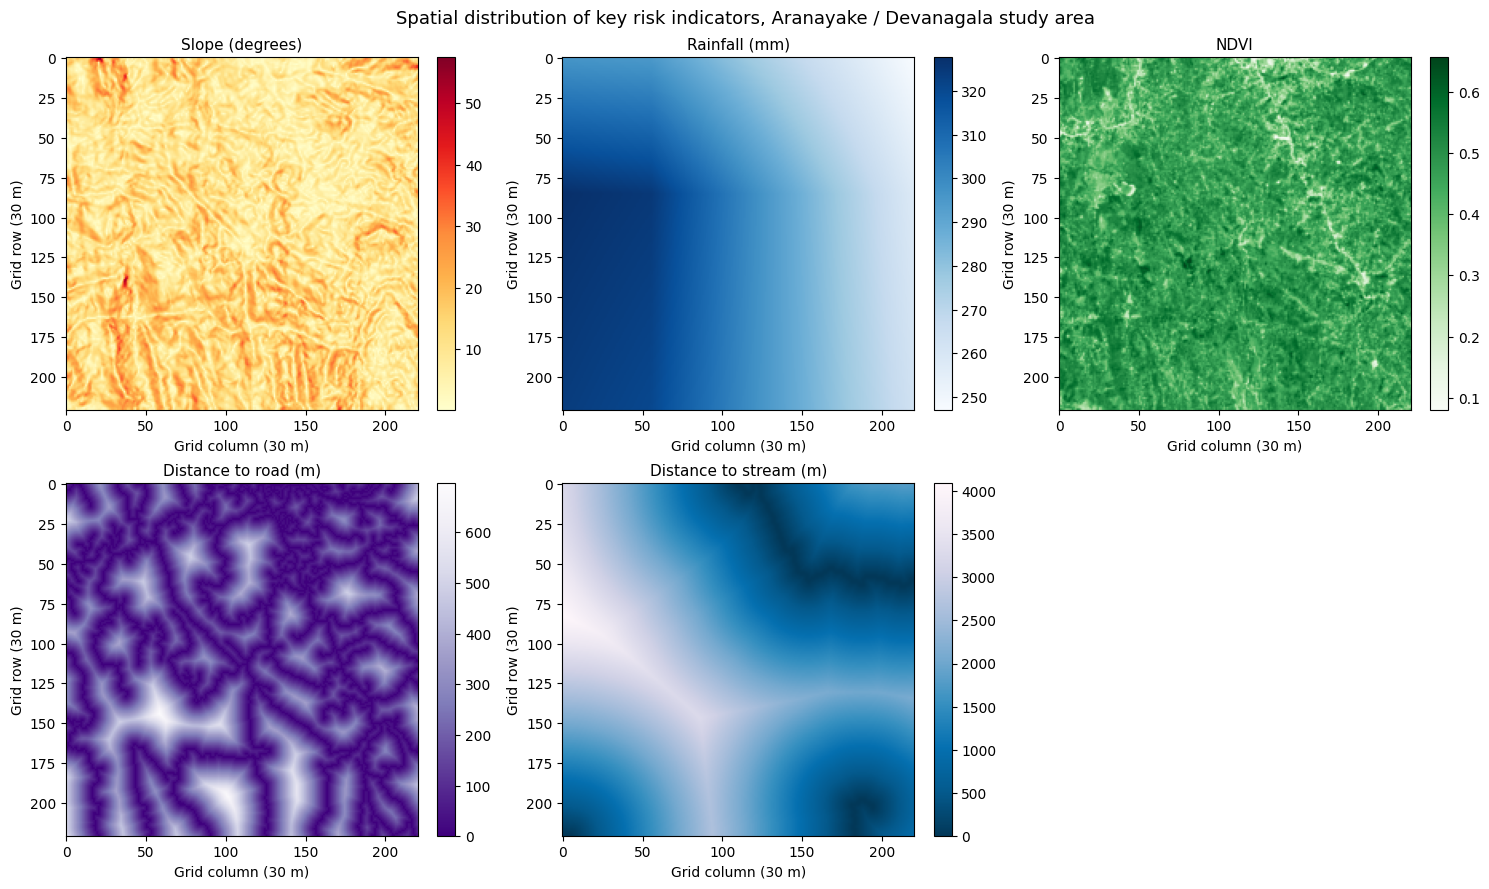

In [6]:
layer_files_spatial = {
    "Slope (degrees)": ("slope_30m.tif", "YlOrRd"),
    "Rainfall (mm)": ("rainfall_30m.tif", "Blues"),
    "NDVI": ("ndvi_30m.tif", "Greens"),
    "Distance to road (m)": ("dist_road_30m.tif", "Purples_r"),
    "Distance to stream (m)": ("dist_stream_30m.tif", "PuBu_r"),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (title, (fname, cmap)) in zip(axes, layer_files_spatial.items()):
    with rasterio.open(f"{PROCESSED_DIR}/{fname}") as src:
        arr = src.read(1)
    im = ax.imshow(arr, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Grid column (30 m)")
    ax.set_ylabel("Grid row (30 m)")
    plt.colorbar(im, ax=ax, fraction=0.046)

axes[-1].axis("off")
plt.suptitle("Spatial distribution of key risk indicators, Aranayake / Devanagala study area", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/fig3_spatial_maps.png", dpi=150, bbox_inches="tight")
plt.show()

This confirms whether elevated values cluster spatially (e.g. steep slope concentrated on one side of the grid) or scatter randomly. Coherent spatial clustering, rather than salt-and-pepper noise, supports the validity of the underlying reprojected layers.

## 4. Correlation Between Indicators

Before combining indicators into a single index, it's worth checking whether any of them are essentially measuring the same thing. If two indicators are very strongly correlated, including both in the index would count that piece of information twice, giving it more influence than intended. This check covers the six indicators actually used in the index calculation in `04_index_construction.ipynb` (slope, NDVI, distance to road, distance to stream, rainfall, and soil clay content), plus curvature, checked here for exploratory purposes even though it is not included in the final index. Elevation and aspect are excluded from this check as neither is used directly in the final score.

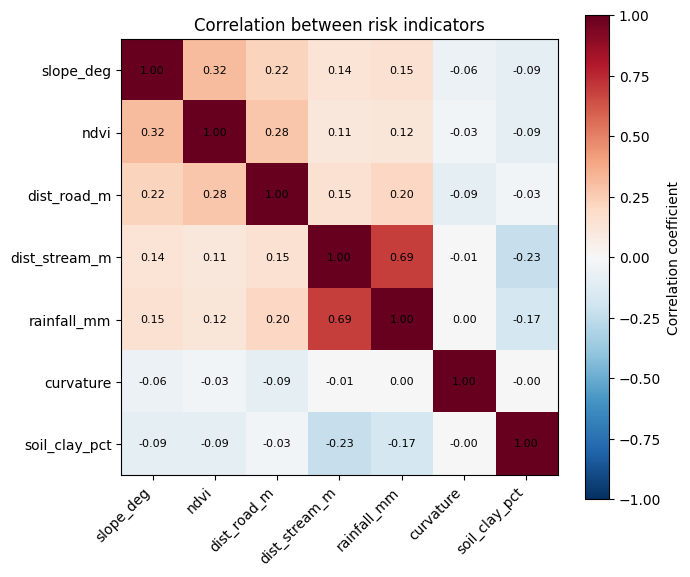

,slope_deg,ndvi,dist_road_m,dist_stream_m,rainfall_mm,curvature,soil_clay_pct
slope_deg,1.00,0.32,0.22,0.14,0.15,-0.06,-0.09
ndvi,0.32,1.00,0.28,0.11,0.12,-0.03,-0.09
dist_road_m,0.22,0.28,1.00,0.15,0.20,-0.09,-0.03
dist_stream_m,0.14,0.11,0.15,1.00,0.69,-0.01,-0.23
rainfall_mm,0.15,0.12,0.20,0.69,1.00,0.00,-0.17
curvature,-0.06,-0.03,-0.09,-0.01,0.00,1.00,-0.00
soil_clay_pct,-0.09,-0.09,-0.03,-0.23,-0.17,-0.00,1.00


In [7]:
corr_columns = ["slope_deg", "ndvi", "dist_road_m", "dist_stream_m", "rainfall_mm", "curvature", "soil_clay_pct"]
correlation = data[corr_columns].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_columns)))
ax.set_yticks(range(len(corr_columns)))
ax.set_xticklabels(corr_columns, rotation=45, ha="right")
ax.set_yticklabels(corr_columns)

for i in range(len(corr_columns)):
    for j in range(len(corr_columns)):
        ax.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation between risk indicators")
plt.colorbar(im, ax=ax, label="Correlation coefficient")
plt.tight_layout()
plt.savefig("../outputs/figures/fig2_correlation.png", dpi=150)
plt.show()

correlation.round(2)

Each cell shows the Pearson correlation coefficient between two indicators, ranging from -1 (perfect negative relationship) through 0 (little linear relationship) to +1 (perfect positive relationship).

The strongest relationship in the raw indicators is between distance to stream and rainfall (`r = 0.69`), indicating that these variables share a substantial spatial pattern within the study area. Correlation alone does not establish causation, and they represent different landslide-related processes: rainfall represents hydrological triggering, while stream proximity represents local bank erosion, undercutting and moisture conditions.

Importantly, the final LS-LRSI does not use raw stream distance directly. In `04_index_construction.ipynb`, stream distance is transformed using `1 / (distance + 1)`, so locations closer to streams receive higher risk contributions. Therefore, the positive correlation between raw stream distance and rainfall does not imply that the two variables simply duplicate the same risk signal in the final index.

Slope and NDVI show a weaker positive relationship (`r = 0.32`). NDVI and distance to road are also weakly positively correlated (`r = 0.28`), while slope has weak positive relationships with distance to road (`r = 0.22`) and distance to stream (`r = 0.14`). Soil clay content shows weak negative correlations with distance to stream (`r = -0.23`) and rainfall (`r = -0.17`). Curvature has negligible linear correlation with the remaining variables.

No pair approaches a near-perfect correlation, so the matrix does not indicate that any two indicators are simple duplicates of one another. The `r = 0.69` rainfall–stream-distance relationship is nevertheless retained as an important spatial association to consider when interpreting the index.